In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import json

In [3]:
BASE_PATH = "/content/drive/MyDrive/electricity-load-system"

df = pd.read_csv(
    f"{BASE_PATH}/data/processed/daily_consumption.csv",
    parse_dates=["datetime"]
)

df = df.dropna().reset_index(drop=True)
df.head()

,datetime,Global_active_power
0,2006-12-16,3.053475
1,2006-12-17,2.354486
2,2006-12-18,1.530435
3,2006-12-19,1.157079
4,2006-12-20,1.545658


In [4]:
lr = joblib.load(f"{BASE_PATH}/models/linear_regression.pkl")
rf = joblib.load(f"{BASE_PATH}/models/random_forest.pkl")

In [5]:
for lag in [1, 2, 3, 7, 14]:
    df[f"lag_{lag}"] = df["Global_active_power"].shift(lag)

df = df.dropna().reset_index(drop=True)

In [6]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_test = test[[f"lag_{l}" for l in [1,2,3,7,14]]]
y_test = test["Global_active_power"]

In [7]:
lr_preds = lr.predict(X_test)
rf_preds = rf.predict(X_test)

In [12]:
import tensorflow as tf

lstm_model = tf.keras.models.load_model(
    f"{BASE_PATH}/models/lstm_model.keras"
)

scaler = joblib.load(f"{BASE_PATH}/models/scaler.pkl")

scaled = scaler.transform(df[["Global_active_power"]])

def create_sequences(data, window=14):
    X = []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
    return np.array(X)

X_seq = create_sequences(scaled, 14)

X_test_seq = X_seq[train_size-14:]

lstm_preds = lstm_model.predict(X_test_seq)
lstm_preds = scaler.inverse_transform(lstm_preds).flatten()

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


In [14]:
import os

model_path = f"{BASE_PATH}/models/lstm_model"

if not os.path.exists(model_path):
    print(f"Error: The model directory '{model_path}' does not exist.")
else:
    print(f"Contents of '{model_path}':")
    print(os.listdir(model_path))

print(f"Contents of '{BASE_PATH}/models/':")
print(os.listdir(f"{BASE_PATH}/models/"))

Error: The model directory '/content/drive/MyDrive/electricity-load-system/models/lstm_model' does not exist.
Contents of '/content/drive/MyDrive/electricity-load-system/models/':
['linear_regression.pkl', 'random_forest.pkl', 'lstm_model.keras', 'scaler.pkl']


In [15]:
y_test_lstm = y_test.values[-len(lstm_preds):]

In [17]:
results = []

def evaluate(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse) # Calculate RMSE by taking the square root of MSE
    }

results.append(evaluate("Linear Regression", y_test, lr_preds))
results.append(evaluate("Random Forest", y_test, rf_preds))
results.append(evaluate("LSTM", y_test_lstm, lstm_preds))

results_df = pd.DataFrame(results)
results_df

,model,MAE,RMSE
0,Linear Regression,0.185571,0.252139
1,Random Forest,0.185050,0.251524
2,LSTM,0.181639,0.243815


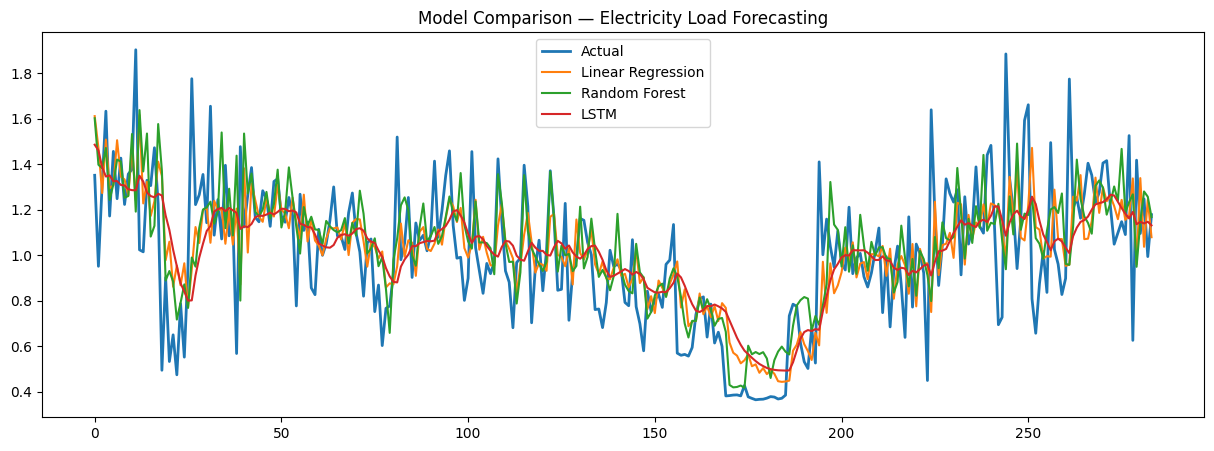

In [18]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values, label="Actual", linewidth=2)
plt.plot(lr_preds, label="Linear Regression")
plt.plot(rf_preds, label="Random Forest")
plt.plot(lstm_preds, label="LSTM")
plt.legend()
plt.title("Model Comparison — Electricity Load Forecasting")
plt.show()

In [21]:
results_df.to_csv(
    f"{BASE_PATH}/experiments/day6_model_comparison.csv",
    index=False
)

In [20]:
!mkdir -p /content/drive/MyDrive/electricity-load-system/experiments

In [22]:
metadata = {
    "dataset": "Household Power Consumption",
    "features": "Lag-based (1,2,3,7,14)",
    "models": ["Linear Regression", "Random Forest", "LSTM"],
    "metric": ["MAE", "RMSE"],
    "best_model": results_df.sort_values("RMSE").iloc[0]["model"]
}

with open(f"{BASE_PATH}/experiments/day6_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

metadata

{'dataset': 'Household Power Consumption',
 'features': 'Lag-based (1,2,3,7,14)',
 'models': ['Linear Regression', 'Random Forest', 'LSTM'],
 'metric': ['MAE', 'RMSE'],
 'best_model': 'LSTM'}

In [23]:
best_model = results_df.sort_values("RMSE").iloc[0]
best_model

,2
model,LSTM
MAE,0.181639
RMSE,0.243815
